# Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from tqdm import tqdm

from rl_signaling.agents import QLearningAgent, UrnAgent
from rl_signaling.env import MultiAgentEnv
from rl_signaling.games import create_random_canonical_game
from rl_signaling.simulation import run_simulation


In [2]:
dump_path = '../results/'

# Urn Agent

In [3]:
n_agents = 2
n_features = 2
agents_observed_variables = {0: [0], 1: [1]}

G = nx.DiGraph()
G.add_nodes_from([0, 1])
G.add_edges_from([(0, 1), (1, 0)])

n_signaling_actions = 2
n_final_actions = 4
n_episodes = 30000

randomcanonical_game = {
    i: create_random_canonical_game(n_features, n_final_actions, n=1, m=0)
    for i in range(n_agents)
}

with_signals, full_information = True, False

urn_rewards_histories = {}
urn_nmi_histories = {}
for init_weights in tqdm([[1, 0], [1, 1], [5, 1], [100, 1]]):
    # Paired comparison: same RNG state at iteration start, the only varying axis is init_weights.
    np.random.seed(0)
    random.seed(0)

    env = MultiAgentEnv(
        n_agents=n_agents,
        n_features=n_features,
        n_signaling_actions=n_signaling_actions,
        n_final_actions=n_final_actions,
        full_information=full_information,
        game_dicts=randomcanonical_game,
        observed_variables=agents_observed_variables,
        agent_type=UrnAgent,
        agent_kwargs={
            'n_observed_features': 1,
            'initialize': True,
            'initialization_weights': init_weights,
        },
        graph=G,
    )

    signal_usage, rewards_history, nmi_history, histories, nature_history = run_simulation(
        env, n_episodes=n_episodes, with_signals=with_signals, plot=False, verbose=False,
    )
    urn_rewards_histories[str(init_weights)] = rewards_history
    urn_nmi_histories[str(init_weights)] = nmi_history


  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:11<00:33, 11.10s/it]

 50%|█████     | 2/4 [00:22<00:22, 11.04s/it]

 75%|███████▌  | 3/4 [00:32<00:10, 10.81s/it]

100%|██████████| 4/4 [00:43<00:00, 10.92s/it]

100%|██████████| 4/4 [00:43<00:00, 10.93s/it]

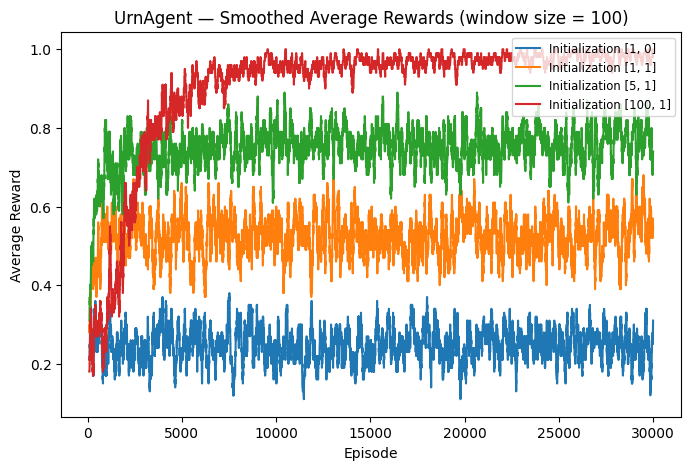

In [4]:
plt.figure(figsize=(8, 5))
for key in urn_rewards_histories:
    window_size = 100
    smoothed_rewards = np.convolve(urn_rewards_histories[key][0], np.ones(window_size) / window_size, mode='valid')
    plt.plot(range(window_size - 1, n_episodes), smoothed_rewards, label=f'Initialization {key}')

plt.title(f'UrnAgent — Smoothed Average Rewards (window size = {window_size})')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.legend(loc='upper right', fontsize='small')

plt.savefig(dump_path + 'initializations_urn_rewards.png', dpi=300)


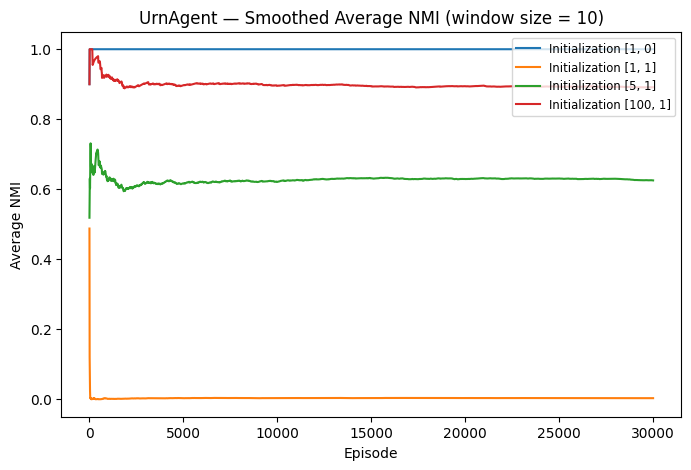

In [5]:
plt.figure(figsize=(8, 5))
for key in urn_nmi_histories:
    smoothed_NMI = [sum(urn_nmi_histories[key][0][j:j+10]) / 10 for j in range(0, n_episodes, 10)]
    plt.plot(range(0, n_episodes, 10), smoothed_NMI, label=f'Initialization {key}')

plt.title('UrnAgent — Smoothed Average NMI (window size = 10)')
plt.xlabel('Episode')
plt.ylabel('Average NMI')
plt.legend(loc='upper right', fontsize='small')

plt.savefig(dump_path + 'initializations_urn_nmi.png', dpi=300)


# Q-Learning Agent


In [6]:
qlearning_rewards_histories = {}
qlearning_nmi_histories = {}
for init_weights in tqdm([[1, 0], [1, 1], [5, 1], [100, 1]]):
    np.random.seed(0)
    random.seed(0)

    env = MultiAgentEnv(
        n_agents=n_agents,
        n_features=n_features,
        n_signaling_actions=n_signaling_actions,
        n_final_actions=n_final_actions,
        full_information=full_information,
        game_dicts=randomcanonical_game,
        observed_variables=agents_observed_variables,
        agent_type=QLearningAgent,
        agent_kwargs={
            'exploration_rate': 0.9652628633727897,
            'exploration_decay': 0.9998122815486062,
            'min_exploration_rate': 1e-10,
            'choice': 'ucb',
            'n_observed_features': 1,
            'initialize': True,
            'initialization_weights': init_weights,
        },
        graph=G,
    )

    signal_usage, rewards_history, nmi_history, histories, nature_history = run_simulation(
        env, n_episodes=n_episodes, with_signals=with_signals, plot=False, verbose=False,
    )
    qlearning_rewards_histories[str(init_weights)] = rewards_history
    qlearning_nmi_histories[str(init_weights)] = nmi_history


  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:09<00:27,  9.27s/it]

 50%|█████     | 2/4 [00:18<00:18,  9.26s/it]

 75%|███████▌  | 3/4 [00:27<00:09,  9.30s/it]

100%|██████████| 4/4 [00:37<00:00,  9.35s/it]

100%|██████████| 4/4 [00:37<00:00,  9.33s/it]

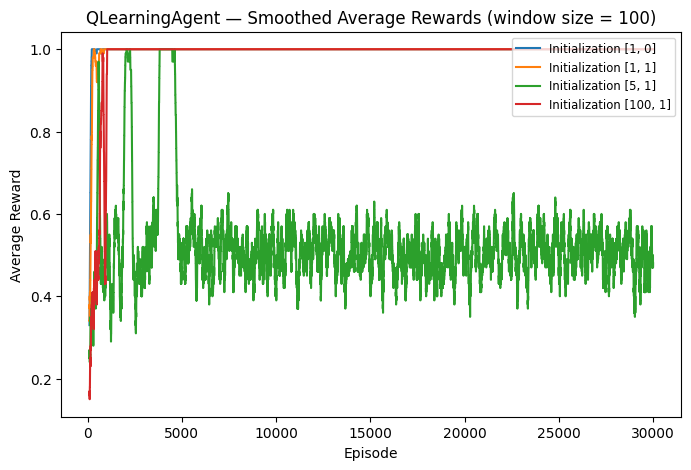

In [7]:
plt.figure(figsize=(8, 5))
for key in qlearning_rewards_histories:
    window_size = 100
    smoothed_rewards = np.convolve(qlearning_rewards_histories[key][0], np.ones(window_size) / window_size, mode='valid')
    plt.plot(range(window_size - 1, n_episodes), smoothed_rewards, label=f'Initialization {key}')

plt.title(f'QLearningAgent — Smoothed Average Rewards (window size = {window_size})')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.legend(loc='upper right', fontsize='small')

plt.savefig(dump_path + 'initializations_rewards.png', dpi=300)


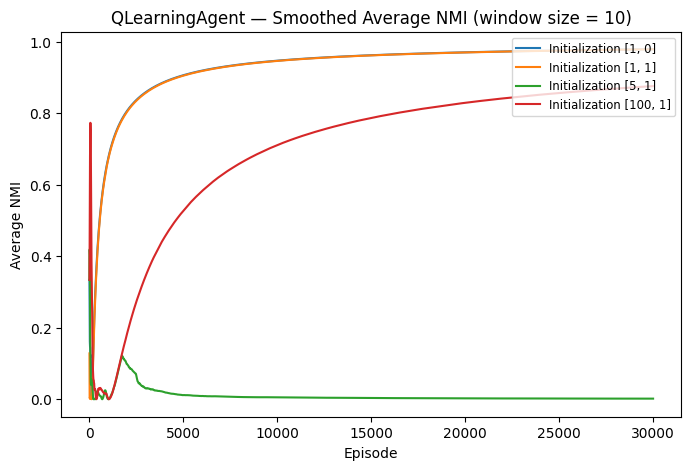

In [8]:
plt.figure(figsize=(8, 5))
for key in qlearning_nmi_histories:
    smoothed_NMI = [sum(qlearning_nmi_histories[key][0][j:j+10]) / 10 for j in range(0, n_episodes, 10)]
    plt.plot(range(0, n_episodes, 10), smoothed_NMI, label=f'Initialization {key}')

plt.title('QLearningAgent — Smoothed Average NMI (window size = 10)')
plt.xlabel('Episode')
plt.ylabel('Average NMI')
plt.legend(loc='upper right', fontsize='small')

plt.savefig(dump_path + 'initializations_nmi.png', dpi=300)


# In Greyscale

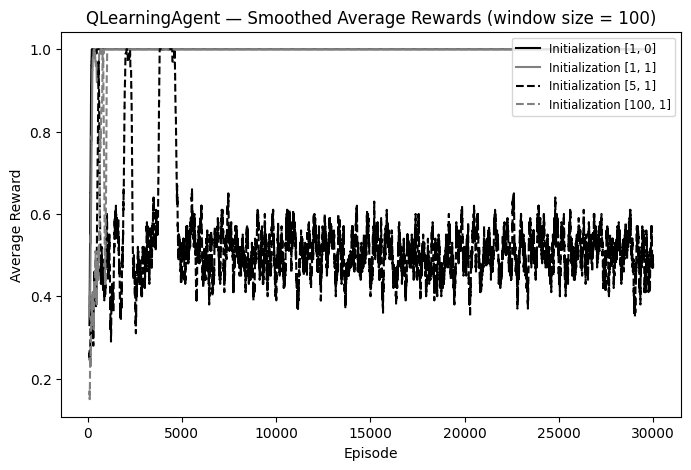

In [9]:
plt.figure(figsize=(8, 5))

grayscale_colors = ['0.0', '0.5']
linestyles = ['-', '--']

for idx, key in enumerate(qlearning_rewards_histories):
    window_size = 100
    smoothed_rewards = np.convolve(
        qlearning_rewards_histories[key][0],
        np.ones(window_size) / window_size,
        mode='valid',
    )

    color = grayscale_colors[idx % 2]
    linestyle = linestyles[(idx // 2) % 2]

    plt.plot(
        range(window_size - 1, n_episodes),
        smoothed_rewards,
        color=color,
        linestyle=linestyle,
        label=f'Initialization {key}',
    )

plt.title(f'QLearningAgent — Smoothed Average Rewards (window size = {window_size})')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.legend(loc='upper right', fontsize='small')


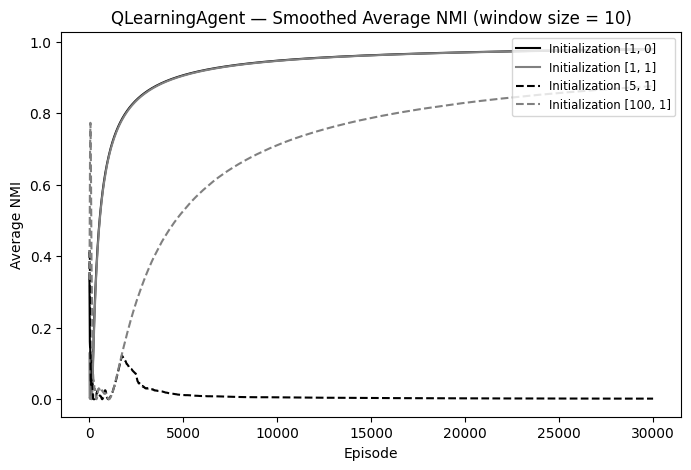

In [10]:
plt.figure(figsize=(8, 5))

grayscale_colors = ['0.0', '0.5']
linestyles = ['-', '--']

for idx, key in enumerate(qlearning_nmi_histories):
    smoothed_NMI = [
        sum(qlearning_nmi_histories[key][0][j:j+10]) / 10
        for j in range(0, n_episodes, 10)
    ]

    color = grayscale_colors[idx % 2]
    linestyle = linestyles[(idx // 2) % 2]

    plt.plot(
        range(0, n_episodes, 10),
        smoothed_NMI,
        color=color,
        linestyle=linestyle,
        label=f'Initialization {key}',
    )

plt.title('QLearningAgent — Smoothed Average NMI (window size = 10)')
plt.xlabel('Episode')
plt.ylabel('Average NMI')
plt.legend(loc='upper right', fontsize='small')
